In [1]:
from datetime import date, timedelta

from sentiment.sources.news.search import NewsSearch
from sentiment.sources.news.extractor import ArticleExtractor
from sentiment.sources.news.repository import ArticleRepository
from sentiment.sources.news.blacklist import SourceBlacklist
from sentiment.sources.news.metrics import ExtractionMetrics
from sentiment.sources.news.pipeline import NewsPipeline
from sentiment.log import setup_logging

In [2]:
import logging
setup_logging(level=logging.FATAL)

In [3]:
news_search = NewsSearch()
repository = ArticleRepository()
blacklist = SourceBlacklist()
metrics = ExtractionMetrics()
extractor = ArticleExtractor(
    blacklist=blacklist,
    workers=20,
    timeout=30,
    source_delay=0.5,
    split_threshold=10,
    metrics=metrics,
)
pipeline = NewsPipeline(
    search=news_search,
    extractor=extractor,
    repository=repository,
    blacklist=blacklist,
)

In [4]:
universe = {
    "NVDA": "Nvidia",
    "GOOGL": "Google",
    "AAPL": "Apple",
}
start_date = date(2025, 4, 2)
end_date = date(2025, 4, 30)


In [5]:
pipeline.run(
    universe=universe,
    start_date=start_date,
    end_date=end_date,
    time_span=timedelta(days=30),
)


start extraction
end extraction
start extraction
end extraction
start extraction
end extraction


In [6]:
import numpy as np
import matplotlib.pyplot as plt

summary = metrics.summary()
print(f"total elapsed:    {summary['total_elapsed']:.1f}s")
print(f"buckets:          {summary['n_finished']}/{summary['n_buckets']}")
print(f"articles:         {summary['total_articles']}")
print(f"peak concurrency: {summary['peak_concurrency']}")
print()
print("slowest buckets:")
for source, duration in summary["slowest"]:
    ev = next(e for e in metrics.events if e.source == source)
    print(f"  {source:<40} {duration:5.1f}s  ({ev.n_stories} stories, {ev.n_articles} articles)")

total elapsed:    97.1s
buckets:          206/206
articles:         1229
peak concurrency: 20

slowest buckets:
  cnet.com [2/2]                            97.1s  (22 stories, 22 articles)
  cnet.com [1/2]                            89.4s  (21 stories, 20 articles)
  cnbc.com [2/2]                            35.1s  (24 stories, 24 articles)
  cnbc.com [1/2]                            34.5s  (24 stories, 24 articles)
  mashable.com [1/2]                        31.9s  (17 stories, 17 articles)


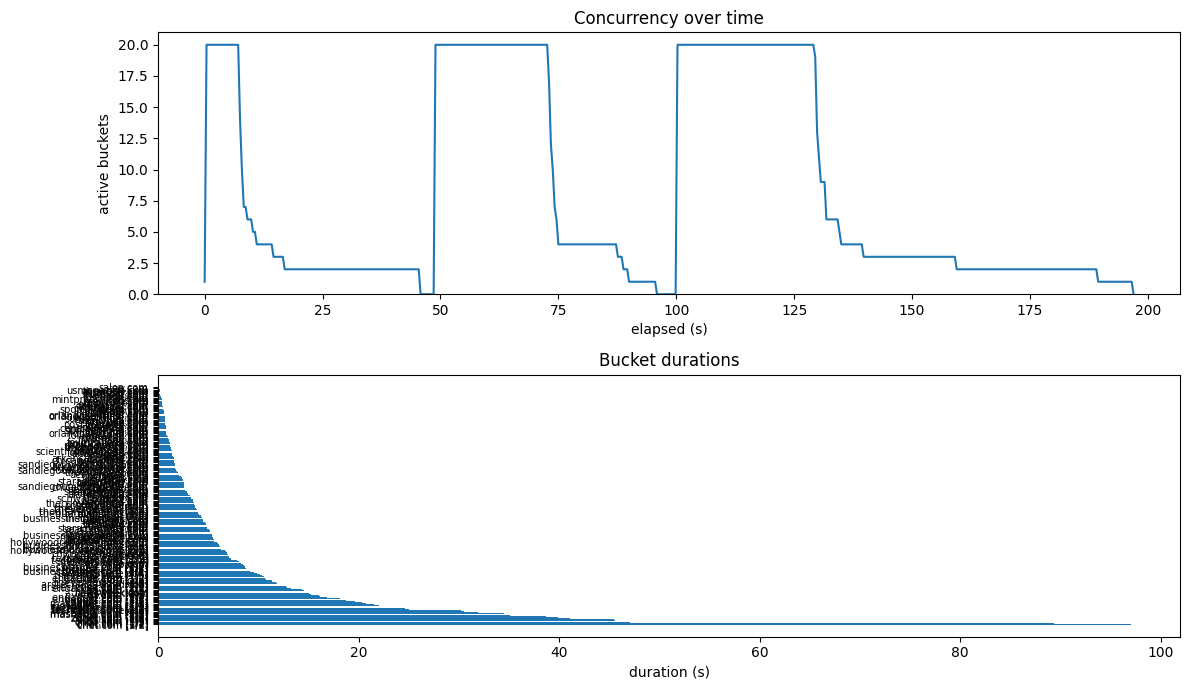

In [7]:
t0 = metrics.events[0].started_at
t1 = metrics._run_end
ts = np.linspace(t0, t1, 500)
concurrency = [metrics.concurrency_at(t) for t in ts]

fig, axes = plt.subplots(2, 1, figsize=(12, 7))

# concurrency over time
axes[0].plot(ts - t0, concurrency)
axes[0].set_xlabel("elapsed (s)")
axes[0].set_ylabel("active buckets")
axes[0].set_title("Concurrency over time")
axes[0].set_ylim(bottom=0)

# per-bucket duration (sorted)
finished = sorted(
    [e for e in metrics.events if e.duration is not None],
    key=lambda e: e.duration,
    reverse=True,
)
labels = [e.source for e in finished]
durations = [e.duration for e in finished]
y = range(len(finished))
axes[1].barh(y, durations)
axes[1].set_yticks(list(y))
axes[1].set_yticklabels(labels, fontsize=7)
axes[1].set_xlabel("duration (s)")
axes[1].set_title("Bucket durations")

plt.tight_layout()
plt.show()